In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)



In [2]:
df = pd.read_csv("ctg-studies.csv")

print("Dimensiones del dataset:", df.shape)
df.head()


Dimensiones del dataset: (1067, 14)


,NCT Number,Study Title,Study Status,Conditions,Interventions,Sponsor,Collaborators,Phases,Enrollment,Study Type,Start Date,Primary Completion Date,Completion Date,Locations
0,NCT02536755,Phase 3b Study to Evaluate Skeletal Response t...,COMPLETED,Gaucher Disease,"DRUG: Eliglustat, GZ385660","Genzyme, a Sanofi Company",NaN,PHASE3,31,INTERVENTIONAL,2015-10-27,2021-06-24,2021-06-24,"Investigational Site Number 124002, Montreal, ..."
1,NCT03330405,Javelin Parp Medley: Avelumab Plus Talazoparib...,TERMINATED,Avelumab in Combination With Talazoparib Will ...,DRUG: Avelumab Phase 1b|DRUG: Talazoparib Phas...,Pfizer,NaN,PHASE1|PHASE2,223,INTERVENTIONAL,2017-10-19,2022-02-22,2023-01-04,"Highlands Oncology Group, Fayetteville, Arkans..."
2,NCT04771975,Connecting Breast Cancer Survivors for Exercise,COMPLETED,Breast Cancer|Breast Neoplasms,BEHAVIORAL: Exercise Counselling|BEHAVIORAL: P...,Jenna Smith,Canadian Cancer Society (CCS),NaN,108,INTERVENTIONAL,2021-05-10,2021-12-30,2022-01-30,"University of Toronto, Toronto, Ontario, M5S 2..."
3,NCT06641609,A Phase I Study of CFT8919 in Patients With Ad...,NOT_YET_RECRUITING,Non-Small Cell Lung Cancer With EGFR Mutation,DRUG: Dose-Escalation (Phase Ia) CFT8919 capsu...,"Betta Pharmaceuticals Co., Ltd.",NaN,PHASE1,166,INTERVENTIONAL,2024-12-13,2025-12-09,2026-04-03,浙江省杭州市拱墅区半山东路1号的英文翻译为： No. 1 Banshan East Road...
4,NCT06719778,Impact of Diet and Lifestyle Modification on t...,RECRUITING,Crohn's Disease,OTHER: Two-stage nutritional therapy concept,Universität Duisburg-Essen,Heidelberg University|German Crohn's and Colit...,NaN,30,INTERVENTIONAL,2024-08-01,2026-04,2027-04,"Sozialstiftung Bamberg, Bamberg, Bavaria, 9604..."


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   NCT Number               1067 non-null   object
 1   Study Title              1067 non-null   object
 2   Study Status             1067 non-null   object
 3   Conditions               1067 non-null   object
 4   Interventions            1046 non-null   object
 5   Sponsor                  1067 non-null   object
 6   Collaborators            444 non-null    object
 7   Phases                   596 non-null    object
 8   Enrollment               1067 non-null   int64 
 9   Study Type               1067 non-null   object
 10  Start Date               1067 non-null   object
 11  Primary Completion Date  1063 non-null   object
 12  Completion Date          1062 non-null   object
 13  Locations                1001 non-null   object
dtypes: int64(1), object(13)
memory usage: 11

In [4]:
# % de nulos por columna (ordenado)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.head(25).to_frame("missing_%"))

# Duplicados exactos de filas
print("Duplicados (filas completas):", df.duplicated().sum())


,missing_%
Collaborators,58.388004
Phases,44.142455
Locations,6.185567
Interventions,1.968135
Completion Date,0.468604
Primary Completion Date,0.374883
NCT Number,0.000000
Study Title,0.000000
Study Status,0.000000
Conditions,0.000000


Duplicados (filas completas): 0


In [5]:
print("Columnas:", len(df.columns))
display(pd.DataFrame({"column": df.columns}))

# algunas columnas con pocos valores únicos (útil para 'status', 'phase', etc.)
nunq = df.nunique(dropna=True).sort_values()
display(nunq.head(30).to_frame("unique_values"))


Columnas: 14


,column
0,NCT Number
1,Study Title
2,Study Status
3,Conditions
4,Interventions
5,Sponsor
6,Collaborators
7,Phases
8,Enrollment
9,Study Type


,unique_values
Study Type,2
Phases,7
Study Status,9
Collaborators,334
Enrollment,406
Sponsor,551
Completion Date,762
Primary Completion Date,776
Start Date,877
Conditions,881


In [6]:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

display(pd.DataFrame({"columns": df.columns}))


,columns
0,nct_number
1,study_title
2,study_status
3,conditions
4,interventions
5,sponsor
6,collaborators
7,phases
8,enrollment
9,study_type


In [7]:
core_cols = [
    "nct_number",
    "study_title",
    "study_status",
    "study_type",
    "phases",
    "conditions",
    "interventions",
    "sponsor",
    "enrollment",
    "start_date",
    "primary_completion_date",
    "completion_date",
    "locations"
]

df_core = df[core_cols].copy()
df_core.head()


,nct_number,study_title,study_status,study_type,phases,conditions,interventions,sponsor,enrollment,start_date,primary_completion_date,completion_date,locations
0,NCT02536755,Phase 3b Study to Evaluate Skeletal Response t...,COMPLETED,INTERVENTIONAL,PHASE3,Gaucher Disease,"DRUG: Eliglustat, GZ385660","Genzyme, a Sanofi Company",31,2015-10-27,2021-06-24,2021-06-24,"Investigational Site Number 124002, Montreal, ..."
1,NCT03330405,Javelin Parp Medley: Avelumab Plus Talazoparib...,TERMINATED,INTERVENTIONAL,PHASE1|PHASE2,Avelumab in Combination With Talazoparib Will ...,DRUG: Avelumab Phase 1b|DRUG: Talazoparib Phas...,Pfizer,223,2017-10-19,2022-02-22,2023-01-04,"Highlands Oncology Group, Fayetteville, Arkans..."
2,NCT04771975,Connecting Breast Cancer Survivors for Exercise,COMPLETED,INTERVENTIONAL,NaN,Breast Cancer|Breast Neoplasms,BEHAVIORAL: Exercise Counselling|BEHAVIORAL: P...,Jenna Smith,108,2021-05-10,2021-12-30,2022-01-30,"University of Toronto, Toronto, Ontario, M5S 2..."
3,NCT06641609,A Phase I Study of CFT8919 in Patients With Ad...,NOT_YET_RECRUITING,INTERVENTIONAL,PHASE1,Non-Small Cell Lung Cancer With EGFR Mutation,DRUG: Dose-Escalation (Phase Ia) CFT8919 capsu...,"Betta Pharmaceuticals Co., Ltd.",166,2024-12-13,2025-12-09,2026-04-03,浙江省杭州市拱墅区半山东路1号的英文翻译为： No. 1 Banshan East Road...
4,NCT06719778,Impact of Diet and Lifestyle Modification on t...,RECRUITING,INTERVENTIONAL,NaN,Crohn's Disease,OTHER: Two-stage nutritional therapy concept,Universität Duisburg-Essen,30,2024-08-01,2026-04,2027-04,"Sozialstiftung Bamberg, Bamberg, Bavaria, 9604..."


In [8]:
date_cols = [
    "start_date",
    "primary_completion_date",
    "completion_date"
]

for col in date_cols:
    df_core[col] = pd.to_datetime(df_core[col], errors="coerce")

df_core[date_cols].info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067 entries, 0 to 1066
Data columns (total 3 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   start_date               1067 non-null   datetime64[ns]
 1   primary_completion_date  1063 non-null   datetime64[ns]
 2   completion_date          1062 non-null   datetime64[ns]
dtypes: datetime64[ns](3)
memory usage: 25.1 KB


In [9]:
df_core["study_duration_days"] = (
    df_core["primary_completion_date"] - df_core["start_date"]
).dt.days

df_core["study_duration_days"].describe()


count    1063.000000
mean     1273.302916
std      1005.367954
min         0.000000
25%       575.000000
50%      1011.000000
75%      1737.000000
max      7306.000000
Name: study_duration_days, dtype: float64

In [10]:
invalid_duration = df_core[
    (df_core["study_duration_days"] <= 0) |
    (df_core["study_duration_days"].isna())
]

print("Filas inválidas:", invalid_duration.shape[0])
invalid_duration[["nct_number", "start_date", "primary_completion_date", "study_duration_days", "study_status"]].head(10)


Filas inválidas: 5


,nct_number,start_date,primary_completion_date,study_duration_days,study_status
258,NCT00154440,2001-11-01,NaT,NaN,UNKNOWN
753,NCT00704743,1998-11-01,NaT,NaN,COMPLETED
1009,NCT00098280,2004-12-01,NaT,NaN,COMPLETED
1032,NCT00001535,1996-03-01,NaT,NaN,COMPLETED
1043,NCT06668077,2024-11-30,2024-11-30,0.0,RECRUITING


Interpretación: 

Duración media ≈ 3.5 años → razonable para clinical trials.

Máx ≈ 20 años → outliers reales (estudios largos o mal cerrados).

5 filas inválidas:

4 → primary_completion_date = NaT

1 → duración = 0 (mismo día, estudio RECRUITING)

Esto es < 0.5% del dataset. No sesga nada.

Decisión metodológica

👉 Vamos a excluir solo las duraciones inválidas porque no se pueden interpretar operativamente.



In [11]:
df_clean = df_core[
    df_core["study_duration_days"].notna() &
    (df_core["study_duration_days"] > 0)
].copy()

print("Antes:", df_core.shape)
print("Después:", df_clean.shape)


Antes: (1067, 14)
Después: (1062, 14)


In [12]:
df_clean["study_duration_days"].describe()


count    1062.000000
mean     1274.501883
std      1005.081017
min         5.000000
25%       575.500000
50%      1011.500000
75%      1737.000000
max      7306.000000
Name: study_duration_days, dtype: float64

In [13]:
status_counts = (
    df_clean["study_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_counts.to_frame("percentage")


,percentage
COMPLETED,37.76
RECRUITING,25.42
ACTIVE_NOT_RECRUITING,12.34
NOT_YET_RECRUITING,8.10
TERMINATED,7.34
UNKNOWN,6.50
WITHDRAWN,1.60
ENROLLING_BY_INVITATION,0.85
SUSPENDED,0.09


In [14]:
duration_by_status = (
    df_clean
    .groupby("study_status")["study_duration_days"]
    .median()
    .sort_values(ascending=False)
)

duration_by_status


study_status
ACTIVE_NOT_RECRUITING      1814.0
SUSPENDED                  1746.0
RECRUITING                 1091.5
COMPLETED                  1006.0
TERMINATED                  880.0
WITHDRAWN                   853.0
UNKNOWN                     730.0
ENROLLING_BY_INVITATION     595.0
NOT_YET_RECRUITING          521.0
Name: study_duration_days, dtype: float64



- **ACTIVE_NOT_RECRUITING** y **SUSPENDED** son los más largos → fricción operativa clara.
- **COMPLETED** (~1006 días) sirve como *baseline*.
- **TERMINATED / WITHDRAWN** duran menos → decisiones tempranas.
- **NOT_YET_RECRUITING** y **ENROLLING_BY_INVITATION** → etapas iniciales, lógico que sean cortas.

Esto ya es un **hallazgo**, no solo un cálculo.


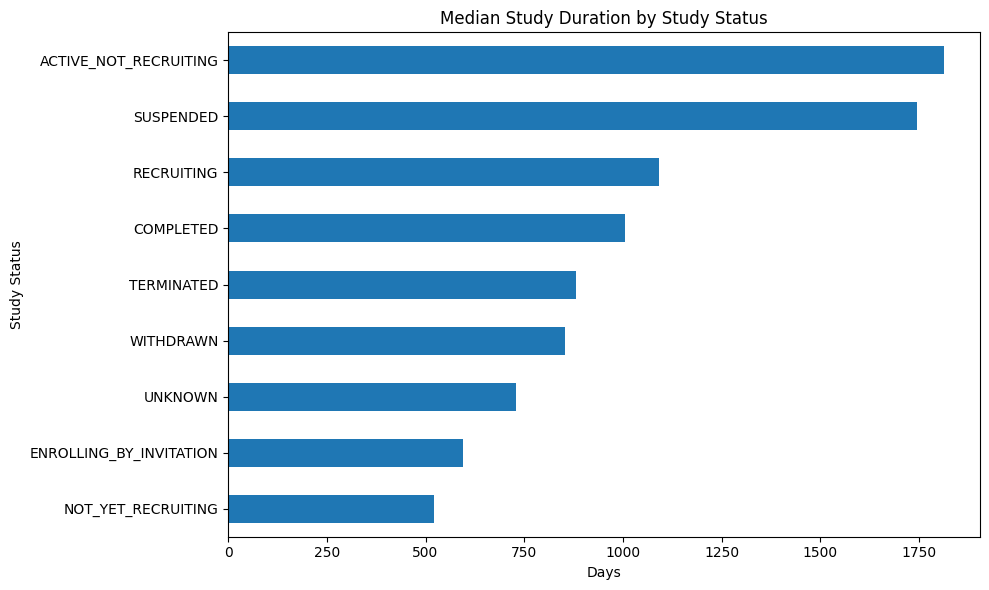

In [15]:
plt.figure(figsize=(10, 6))

duration_by_status.sort_values().plot(
    kind="barh"
)

plt.title("Median Study Duration by Study Status")
plt.xlabel("Days")
plt.ylabel("Study Status")
plt.tight_layout()
plt.show()


### Lectura crítica (breve)

- **ACTIVE_NOT_RECRUITING** y **SUSPENDED** concentran las duraciones medianas más altas → clara **fricción operativa** (pausas, cuellos de botella regulatorios o de reclutamiento).
- **COMPLETED** (~1006 días) funciona como **baseline** realista del ciclo de vida típico.
- **RECRUITING** supera a **COMPLETED**, sugiriendo que la fase de reclutamiento es un **driver principal de extensión temporal**.
- **TERMINATED** y **WITHDRAWN** muestran duraciones menores → **decisiones tempranas** reducen costos hundidos.
- **NOT_YET_RECRUITING** y **ENROLLING_BY_INVITATION** son las más cortas → coherente con **etapas iniciales**.

Esto ya es un **hallazgo operativo accionable**, no solo descriptivo.


In [16]:
duration_by_phase = (
    df_clean
    .dropna(subset=["phases"])
    .groupby("phases")["study_duration_days"]
    .median()
    .sort_values(ascending=False)
)

duration_by_phase


phases
PHASE2|PHASE3    1746.0
EARLY_PHASE1     1581.0
PHASE1|PHASE2    1561.0
PHASE3           1409.5
PHASE2           1188.0
PHASE1           1109.0
PHASE4            707.0
Name: study_duration_days, dtype: float64

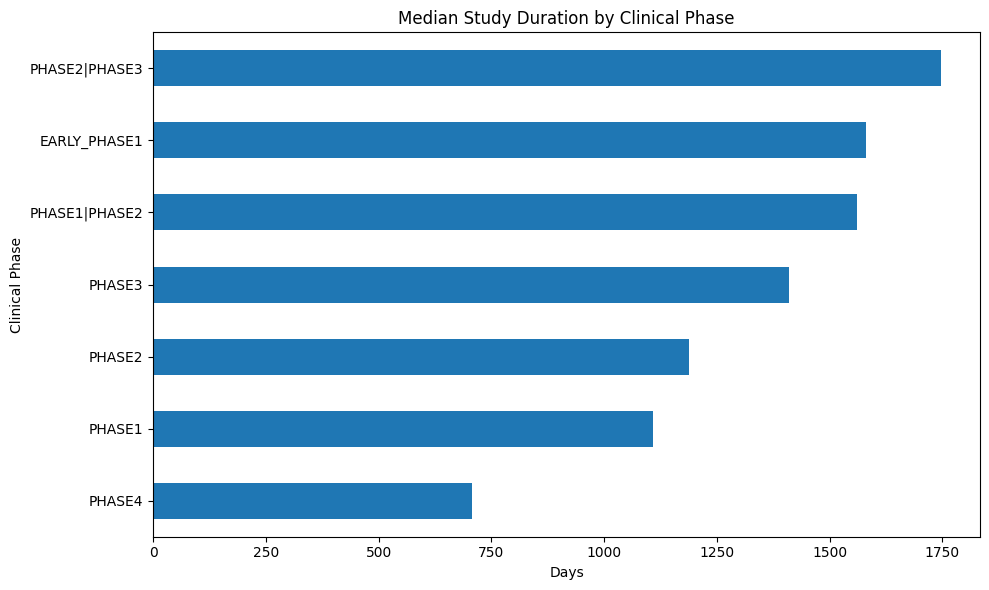

In [17]:
plt.figure(figsize=(10, 6))

duration_by_phase.sort_values().plot(
    kind="barh"
)

plt.title("Median Study Duration by Clinical Phase")
plt.xlabel("Days")
plt.ylabel("Clinical Phase")
plt.tight_layout()
plt.show()


In [18]:
duration_by_type = (
    df_clean
    .groupby("study_type")["study_duration_days"]
    .median()
    .sort_values(ascending=False)
)

duration_by_type


study_type
OBSERVATIONAL     1094.5
INTERVENTIONAL    1003.0
Name: study_duration_days, dtype: float64



- **OBSERVATIONAL** presenta una duración mediana mayor que **INTERVENTIONAL** → menor presión regulatoria no implica necesariamente menor tiempo operativo.
- **INTERVENTIONAL** (~1003 días) es consistente con el *baseline* observado en estudios **COMPLETED**, lo que refuerza su rol como referencia operativa.
- La diferencia moderada sugiere que el **tipo de estudio explica menos variabilidad temporal** que el estatus o la fase clínica.

Esto indica que la **fase y el estado del estudio pesan más que el diseño** en la duración total.


In [19]:
top_sponsors = (
    df_clean["sponsor"]
    .value_counts()
    .head(10)
    .index
)

duration_by_sponsor = (
    df_clean[df_clean["sponsor"].isin(top_sponsors)]
    .groupby("sponsor")["study_duration_days"]
    .median()
    .sort_values(ascending=False)
)

duration_by_sponsor


sponsor
National Cancer Institute (NCI)             1888.5
Merck Sharp & Dohme LLC                     1685.0
Hoffmann-La Roche                           1627.5
Astellas Pharma Global Development, Inc.    1573.5
Mayo Clinic                                 1510.0
Takeda                                      1328.5
VA Office of Research and Development       1217.5
Novartis Pharmaceuticals                    1092.5
Pfizer                                      1081.5
GlaxoSmithKline                              992.5
Name: study_duration_days, dtype: float64

### Lectura crítica (breve)

- **National Cancer Institute (NCI)** presenta la mayor duración mediana → estudios grandes, multicéntricos y de alta complejidad operativa.
- **Big Pharma** (Merck, Roche, Astellas, Takeda, Novartis, Pfizer, GSK) muestra duraciones elevadas pero relativamente homogéneas → procesos estandarizados, pero con alta carga regulatoria.
- **Instituciones académicas** (Mayo Clinic) se sitúan en rangos altos → menor presión comercial no implica menor duración.
- La variabilidad entre sponsors sugiere que la **gobernanza operativa y el portafolio terapéutico** influyen tanto como la fase clínica.

Esto apunta a que el **sponsor es un determinante operativo relevante**, no solo un atributo administrativo.


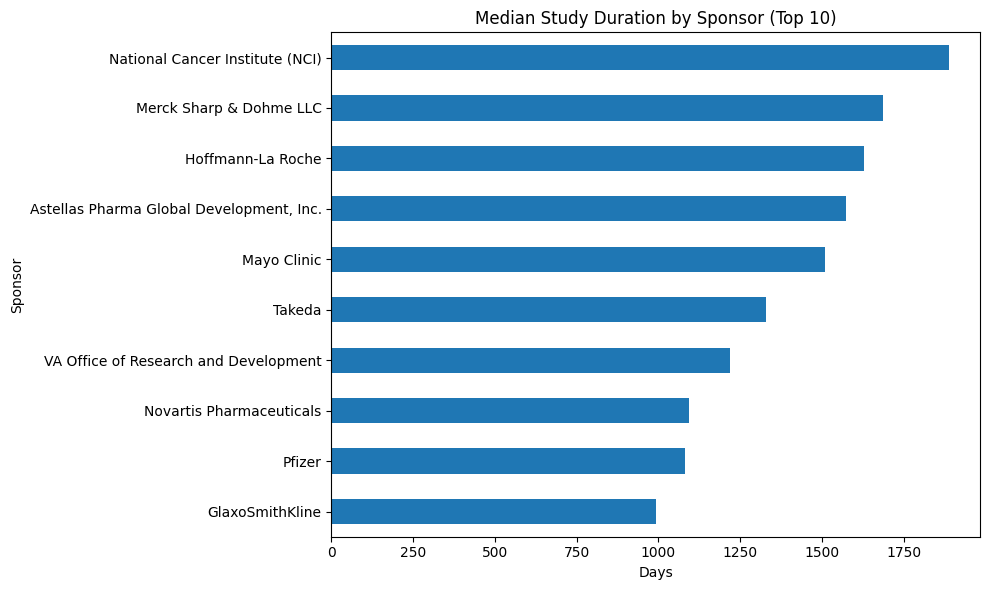

In [20]:
plt.figure(figsize=(10, 6))

duration_by_sponsor.sort_values().plot(
    kind="barh"
)

plt.title("Median Study Duration by Sponsor (Top 10)")
plt.xlabel("Days")
plt.ylabel("Sponsor")
plt.tight_layout()
plt.show()


### Lectura crítica (breve)

- **National Cancer Institute (NCI)** destaca con la mayor duración mediana → estudios oncológicos grandes, multicéntricos y con alta complejidad regulatoria y logística.
- **Big Pharma** (Merck, Roche, Astellas, Takeda, Novartis, Pfizer, GSK) presenta duraciones largas pero relativamente concentradas → evidencia de **procesos maduros**, aunque inherentemente largos.
- **Mayo Clinic** y **VA Office of Research and Development** se alinean con duraciones elevadas → la investigación académica y gubernamental no es más “ágil” por defecto.
- La dispersión entre sponsors sugiere que la **estrategia institucional, el área terapéutica y la escala del estudio** influyen más que el simple volumen de recursos.

Esto refuerza que la **eficiencia operativa no depende solo del sponsor**, sino de cómo gestiona complejidad, fase y reclutamiento.


## Síntesis ejecutiva

Este proyecto analiza la duración y eficiencia operativa de estudios clínicos utilizando datos públicos de ClinicalTrials.gov.  
El objetivo es identificar **factores estructurales** asociados con estudios más largos o más cortos, con implicaciones directas para planeación, gestión y toma de decisiones operativas.

Los análisis se enfocan en:
- Estado del estudio
- Fase clínica
- Tipo de estudio
- Sponsor

## Hallazgos clave
### Lectura crítica (breve)

- El **estatus del estudio** es uno de los principales determinantes de duración: estudios *ACTIVE_NOT_RECRUITING* y *SUSPENDED* muestran las mayores duraciones medianas, reflejando fricción operativa.
- La **fase clínica** tiene un impacto estructural claro: fases combinadas y *PHASE 3* concentran los estudios más largos.
- El **tipo de estudio** (interventional vs observational) explica una menor proporción de la variabilidad temporal.
- El **sponsor** influye de manera significativa, especialmente en instituciones públicas y grandes farmacéuticas, donde la escala y complejidad aumentan la duración.

## Implicaciones operativas

Los resultados sugieren que la duración de los estudios clínicos está menos influenciada por el diseño formal del estudio y más por:

- Complejidad regulatoria acumulada
- Gestión del reclutamiento
- Transiciones entre fases
- Gobernanza institucional del sponsor

Desde una perspectiva operativa, esto implica que **intervenciones tempranas en reclutamiento y gestión de fases** pueden tener mayor impacto que cambios marginales en el diseño del estudio.

## Limitaciones del análisis

- El dataset es **observacional** y no permite inferir causalidad.
- La duración se estimó usando *primary completion date* como proxy del cierre operativo.
- No se controló explícitamente por:
  - Área terapéutica
  - Tamaño real de muestra
  - Complejidad geográfica o multicéntrica
- Algunos campos presentan valores faltantes, aunque su impacto es limitado.


## Conclusiones

La eficiencia operativa en estudios clínicos depende principalmente de **factores estructurales** como el estatus, la fase clínica y el sponsor, más que del tipo de estudio en sí.

Este análisis demuestra que los datos públicos pueden utilizarse para:
- Identificar cuellos de botella operativos
- Establecer *benchmarks* realistas de duración
- Apoyar decisiones estratégicas en planeación de estudios clínicos

## Próximos pasos

Con información adicional, futuros análisis podrían incluir:
- Modelos predictivos de duración del estudio
- Análisis por área terapéutica
- Impacto del número de localizaciones
- Relación entre duración y tamaño de enrolamiento

